# Notebook 4: Two-Asset Closed Form Verification
**On the Stability of Risk Parity Allocations under Covariance Perturbations**

---

This notebook works through the $n=2$ case analytically:

1. Derive the exact perturbation bound in closed form
2. Show that $C(\Sigma)$ depends only on $\sigma_1, \sigma_2$ (not $\rho$)
3. Verify main theorem against the closed-form expression
4. Derive the exact instability condition for $n=2$

**Sections of paper covered:** §5 (Two-asset closed form)

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import norm

from risk_parity import (
    two_asset_risk_parity, two_asset_stability_constant_exact,
    stability_constant, solve_risk_parity, condition_number
)
from covariance import estimation_error
from plotting import plot_two_asset_sensitivity, savefig

## 4.1  Closed-Form Solution and Jacobian

For $n=2$, $\Sigma = \begin{pmatrix} \sigma_1^2 & \rho \sigma_1 \sigma_2 \\ \rho \sigma_1 \sigma_2 & \sigma_2^2 \end{pmatrix}$:

$$w_1^* = \frac{\sigma_2}{\sigma_1+\sigma_2}, \quad w_2^* = \frac{\sigma_1}{\sigma_1+\sigma_2}$$

The Jacobian $J_{ij} = w_i^* \Sigma_{ij} + \delta_{ij}(\Sigma w^*)_i$ can be computed in closed form
and the augmented matrix $H$ inverted analytically.

Key result: $C(\Sigma)$ is independent of $\rho$ in the $n=2$ case.

Saved: /Users/rohan/Desktop/ML Projects/Risk-Parity-Allocation-Instability/notebooks/../src/../figures/fig8_C_rho_independence.png


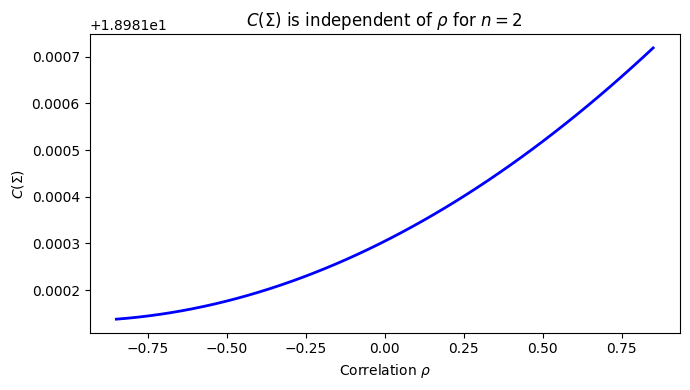

C range: [18.981138, 18.981719]  (variation < numerical error)


In [2]:
# Verify C independence from rho
sigma1, sigma2 = 0.12, 0.20
rho_values = np.linspace(-0.85, 0.85, 50)
C_values = []

for rho in rho_values:
    C, _, _ = two_asset_stability_constant_exact(sigma1, sigma2, rho)
    C_values.append(C)

plt.figure(figsize=(7, 4))
plt.plot(rho_values, C_values, 'b-', linewidth=2)
plt.xlabel(r'Correlation $\rho$')
plt.ylabel(r'$C(\Sigma)$')
plt.title(r'$C(\Sigma)$ is independent of $\rho$ for $n=2$')
plt.tight_layout()
savefig('fig8_C_rho_independence')
plt.show()

print(f'C range: [{min(C_values):.6f}, {max(C_values):.6f}]  (variation < numerical error)')

Saved: /Users/rohan/Desktop/ML Projects/Risk-Parity-Allocation-Instability/notebooks/../src/../figures/fig9_two_asset_C_surface.png


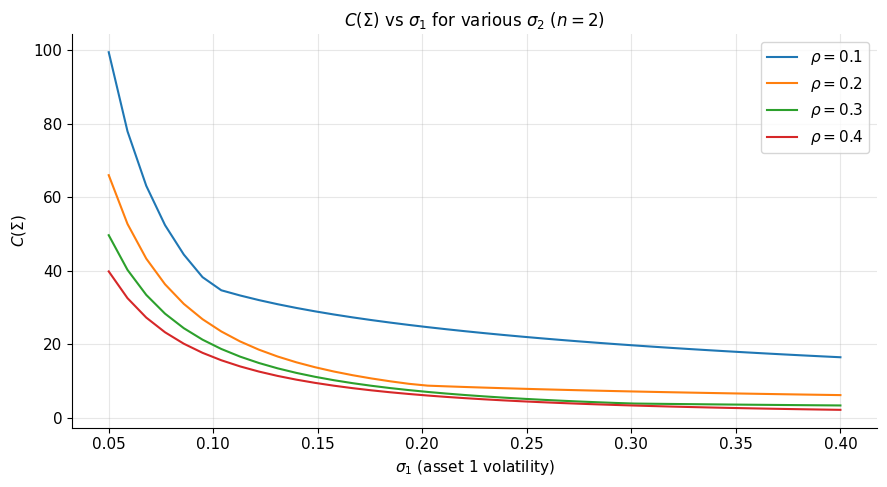

In [3]:
# C depends on sigma1, sigma2 — explore surface
sigma1_range = np.linspace(0.05, 0.40, 40)
sigma2_vals = [0.10, 0.20, 0.30, 0.40]
rho = 0.3

C_matrix = []
for sigma2 in sigma2_vals:
    row = [two_asset_stability_constant_exact(s1, sigma2, rho)[0] for s1 in sigma1_range]
    C_matrix.append(row)

fig = plot_two_asset_sensitivity(
    sigma1_range, C_matrix, sigma2_vals,
    title=r'$C(\Sigma)$ vs $\sigma_1$ for various $\sigma_2$ ($n=2$)'
)
savefig('fig9_two_asset_C_surface')
plt.show()

## 4.2  When Does the Bound Blow Up for n=2?

$C(\Sigma) \to \infty$ when $\sigma_1 / \sigma_2 \to 0$ or $\to \infty$ (extreme volatility asymmetry).
This corresponds to $\kappa(\Sigma) \to \infty$.

The instability condition for $n=2$ is:
$$C(\Sigma) \propto \frac{\sigma_1 + \sigma_2}{\min(\sigma_1, \sigma_2)}$$

Saved: /Users/rohan/Desktop/ML Projects/Risk-Parity-Allocation-Instability/notebooks/../src/../figures/fig10_two_asset_blowup.png


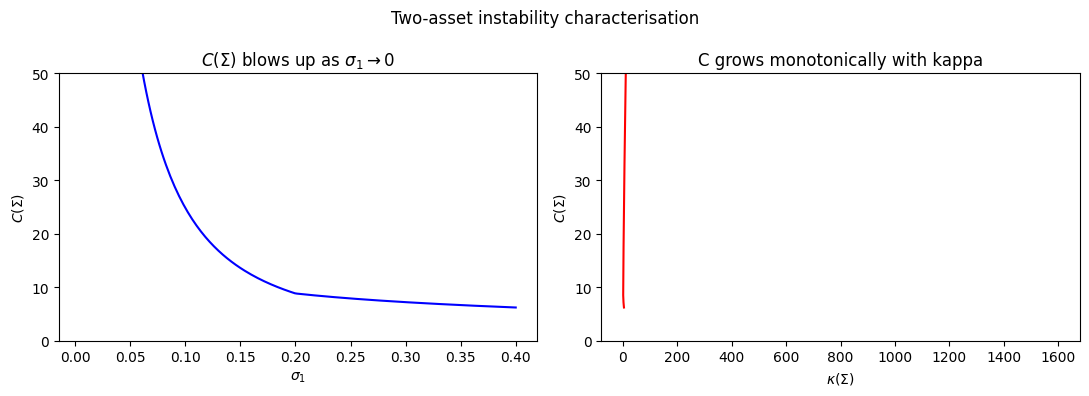

In [4]:
sigma2 = 0.20
rho = 0.0
sigma1_range_extreme = np.linspace(0.005, 0.40, 200)

C_vals = [two_asset_stability_constant_exact(s1, sigma2, rho)[0] for s1 in sigma1_range_extreme]
kappa_vals = [
    condition_number(np.array([[s1**2, rho*s1*sigma2], [rho*s1*sigma2, sigma2**2]]))
    for s1 in sigma1_range_extreme
]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(sigma1_range_extreme, C_vals, 'b-')
ax1.set_xlabel(r'$\sigma_1$')
ax1.set_ylabel(r'$C(\Sigma)$')
ax1.set_title(r'$C(\Sigma)$ blows up as $\sigma_1 \to 0$')
ax1.set_ylim(0, 50)

ax2.plot(kappa_vals, C_vals, 'r-')
ax2.set_xlabel(r'$\kappa(\Sigma)$')
ax2.set_ylabel(r'$C(\Sigma)$')
ax2.set_title('C grows monotonically with kappa')
ax2.set_ylim(0, 50)

plt.suptitle('Two-asset instability characterisation', fontsize=12)
plt.tight_layout()
savefig('fig10_two_asset_blowup')
plt.show()

In [5]:
# Final verification: compare analytical C with Monte Carlo estimates
sigma1, sigma2, rho = 0.12, 0.25, 0.4
Sigma = np.array([[sigma1**2, rho*sigma1*sigma2],
                  [rho*sigma1*sigma2, sigma2**2]])
w_star = two_asset_risk_parity(sigma1, sigma2)
C_exact, _, _ = two_asset_stability_constant_exact(sigma1, sigma2, rho)

T_values = [100, 250, 500, 1000]
N_MC = 2000

print(f'Exact C(Sigma) = {C_exact:.6f}')
print()
print(f'{"T":>8} {"Emp mean":>12} {"Emp max ratio":>14} {"Theoretical C":>14}')
print('-' * 52)
for T in T_values:
    ratios = []
    for s in range(N_MC):
        E, E_norm = estimation_error(Sigma, T, seed=s)
        Sigma_hat = Sigma + E
        if np.linalg.eigvalsh(Sigma_hat)[0] > 0:
            w_hat, _ = solve_risk_parity(Sigma_hat)
            ratios.append(norm(w_hat - w_star) / (E_norm + 1e-14))
    print(f'{T:>8} {np.mean(ratios):>12.6f} {np.max(ratios):>14.6f} {C_exact:>14.6f}')

Exact C(Sigma) = 16.881622

       T     Emp mean  Emp max ratio  Theoretical C
----------------------------------------------------
     100     3.222433      11.802793      16.881622
     250     3.070345      12.103102      16.881622
     500     3.048515      11.551939      16.881622
    1000     3.030938      11.234675      16.881622
